## >> Import Libraries & load Dataset

In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [88]:
# LOAD THE TITANIC DATASET FROM SEABORN AND PREVIEW THE FIRST 10 ROWS
titanic_DF = sns.load_dataset('titanic')
titanic_DF.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## >> Select Numeric Columns & Handle Missing Values

In [89]:
# SELECT ONLY NUMERICAL COLUMNS FOR INITIAL ANALYSIS
numeric_Cols = titanic_DF[['survived', 'pclass', 'age', 'parch']]
numeric_Cols.head(10)

,survived,pclass,age,parch
0,0,3,22.0,0
1,1,1,38.0,0
2,1,3,26.0,0
3,1,1,35.0,0
4,0,3,35.0,0
5,0,3,NaN,0
6,0,1,54.0,0
7,0,3,2.0,1
8,1,3,27.0,2
9,1,2,14.0,0


In [90]:
# FILL MISSING VALUES WITH COLUMN MEAN
mean_apply = numeric_Cols.fillna(numeric_Cols.mean())
mean_apply.head(10)

,survived,pclass,age,parch
0,0,3,22.000000,0
1,1,1,38.000000,0
2,1,3,26.000000,0
3,1,1,35.000000,0
4,0,3,35.000000,0
5,0,3,29.699118,0
6,0,1,54.000000,0
7,0,3,2.000000,1
8,1,3,27.000000,2
9,1,2,14.000000,0


## >> Create 'X' & 'y' and Train Test Split

In [91]:
# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
X = mean_apply.drop('survived', axis=1)
y = mean_apply['survived']

# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=51)

# DISPLAY THE SHAPES OF ALL SPLIT DATASETS
print(f":> FEATURES SHAPE (X): {X.shape}")
print(f":> TARGET SHAPE (y): {y.shape}")

print(f"\n:> TRAINING FEATURES SHAPE (X_train): {X_train.shape}")
print(f":> TESTING FEATURES SHAPE (X_test): {X_test.shape}")
print(f":> TRAINING TARGET SHAPE (y_train): {y_train.shape}")
print(f":> TESTING TARGET SHAPE (y_test): {y_test.shape}")

:> FEATURES SHAPE (X): (891, 3)
:> TARGET SHAPE (y): (891,)

:> TRAINING FEATURES SHAPE (X_train): (712, 3)
:> TESTING FEATURES SHAPE (X_test): (179, 3)
:> TRAINING TARGET SHAPE (y_train): (712,)
:> TESTING TARGET SHAPE (y_test): (179,)


## >> Standard Scaler and Fit the Scaler

In [92]:
scaler = StandardScaler()           # INITIALIZE STANDARD SCALER (Z-SCORE NORMALIZATION)
scaler.fit(X_train)                 # FIT THE SCALER ON TRAINING DATA ONLY

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## >> Check Mean & Standard Deviation

In [93]:
# VIEW THE MEAN VALUES CALCULATED BY THE SCALER
scaler.mean_

array([ 2.30617978, 29.55409121,  0.39185393])

In [94]:
# VIEW THE STANDARD DEVIATION VALUES CALCULATED BY THE SCALER
scaler.scale_

array([ 0.84405789, 12.99162985,  0.79647463])

In [95]:
# DISPLAY SUMMARY STATISTICS OF ORIGINAL TRAINING DATA
X_train.describe()

,pclass,age,parch
count,712.000000,712.000000,712.000000
mean,2.306180,29.554091,0.391854
std,0.844651,13.000763,0.797035
min,1.000000,0.420000,0.000000
25%,1.750000,22.000000,0.000000
50%,3.000000,29.699118,0.000000
75%,3.000000,35.000000,0.000000
max,3.000000,71.000000,5.000000


## >> Transform Data

In [96]:
# TRANSFORM BOTH TRAINING AND TESTING DATA USING STANDARD SCALER
trnfm_X_train = scaler.transform(X_train)
trnfm_X_test = scaler.transform(X_test)

# CONVERT TRANSFORMED ARRAYS BACK TO DATAFRAMES FOR BETTER VISUALIZATION
complete_X_train = pd.DataFrame(trnfm_X_train, columns=["pclass", "age", "parch"])
complete_X_test = pd.DataFrame(trnfm_X_test, columns=["pclass", "age", "parch"])

# DISPLAY SUMMARY STATISTICS AFTER STANDARD SCALING (MEAN SHOULD BE ~0, STD ~1)
complete_X_train.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.00,0.00,0.00
std,1.00,1.00,1.00
min,-1.55,-2.24,-0.49
25%,-0.66,-0.58,-0.49
50%,0.82,0.01,-0.49
75%,0.82,0.42,-0.49
max,0.82,3.19,5.79


## >> MinMax Scaler and Fit the MinMax

In [97]:
MinMaxSclr = MinMaxScaler()             # INITIALIZE MIN-MAX SCALER (NORMALIZATION TO RANGE [0, 1])
MinMaxSclr.fit(X_train)                 # FIT MIN-MAX SCALER ON TRAINING DATA

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [98]:
# TRANSFORM BOTH TRAINING AND TESTING DATA USING MIN-MAX SCALER
trnfm_X_train_MMC = MinMaxSclr.transform(X_train)
trnfm_X_test_MMC = MinMaxSclr.transform(X_test)

# CONVERT TRANSFORMED ARRAYS BACK TO DATAFRAMES
complete_X_train_MMC = pd.DataFrame(trnfm_X_train_MMC, columns=['pclass', 'age', 'parch'])
complete_X_test_MMC = pd.DataFrame(trnfm_X_test_MMC, columns=['pclass', 'age', 'parch'])

# DISPLAY SUMMARY STATISTICS AFTER MIN-MAX SCALING (ALL VALUES BETWEEN 0 AND 1)
complete_X_train_MMC.describe().round(2)

,pclass,age,parch
count,712.00,712.00,712.00
mean,0.65,0.41,0.08
std,0.42,0.18,0.16
min,0.00,0.00,0.00
25%,0.38,0.31,0.00
50%,1.00,0.41,0.00
75%,1.00,0.49,0.00
max,1.00,1.00,1.00


## >> Pairplots


=>> PAIRPLOT OF ORIGINAL TRAINING DATA (BEFORE SCALING) >>


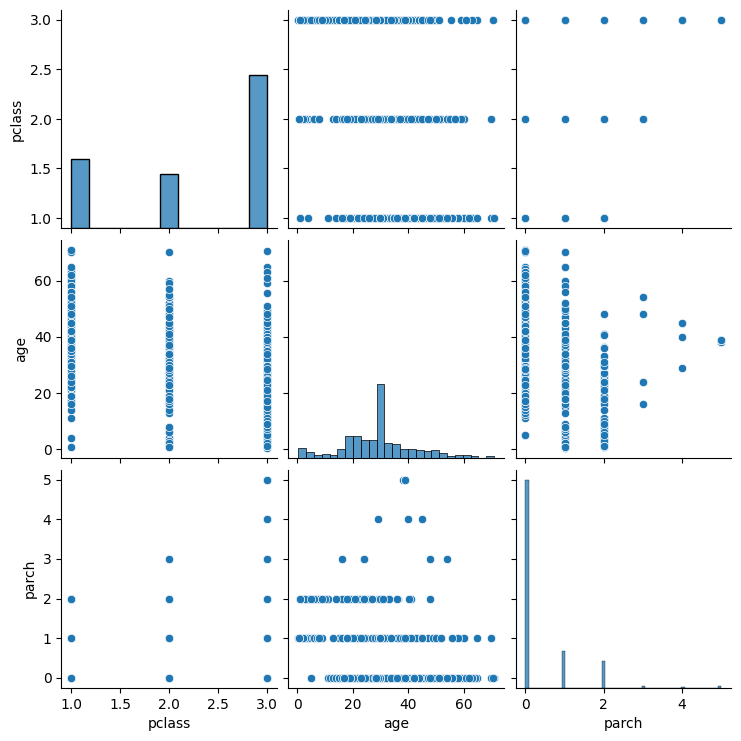

In [99]:
# VISUALIZE PAIRWISE RELATIONSHIPS IN ORIGINAL DATA
print("\n=>> PAIRPLOT OF ORIGINAL TRAINING DATA (BEFORE SCALING) >>")
sns.pairplot(X_train)


=>> PAIRPLOT AFTER STANDARD SCALING (MEAN=0, STD=1) >>


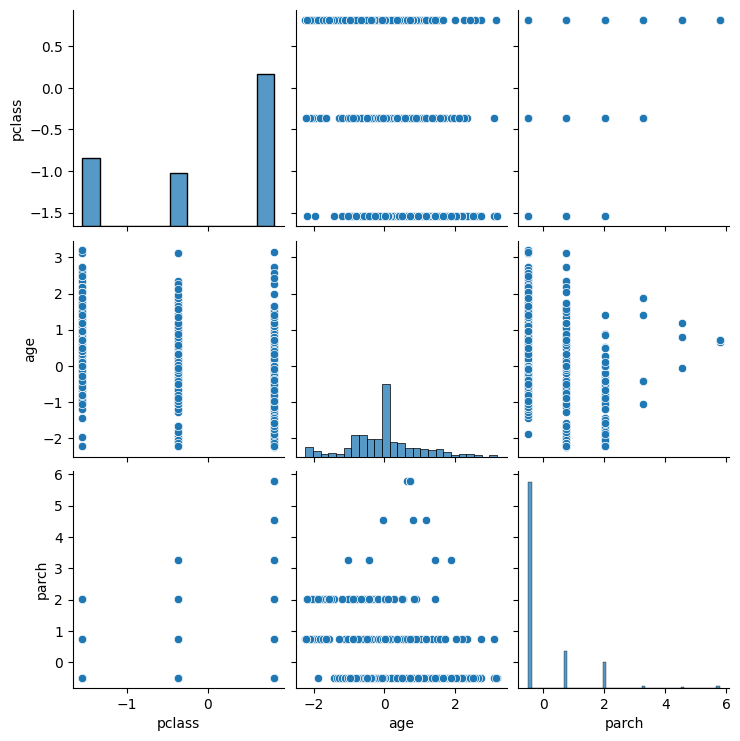

In [100]:
# VISUALIZE PAIRWISE RELATIONSHIPS AFTER STANDARD SCALING (Z-SCORE)
print("\n=>> PAIRPLOT AFTER STANDARD SCALING (MEAN=0, STD=1) >>")
sns.pairplot(complete_X_train)


=>> PAIRPLOT AFTER MIN-MAX SCALING (RANGE 0-1) >>


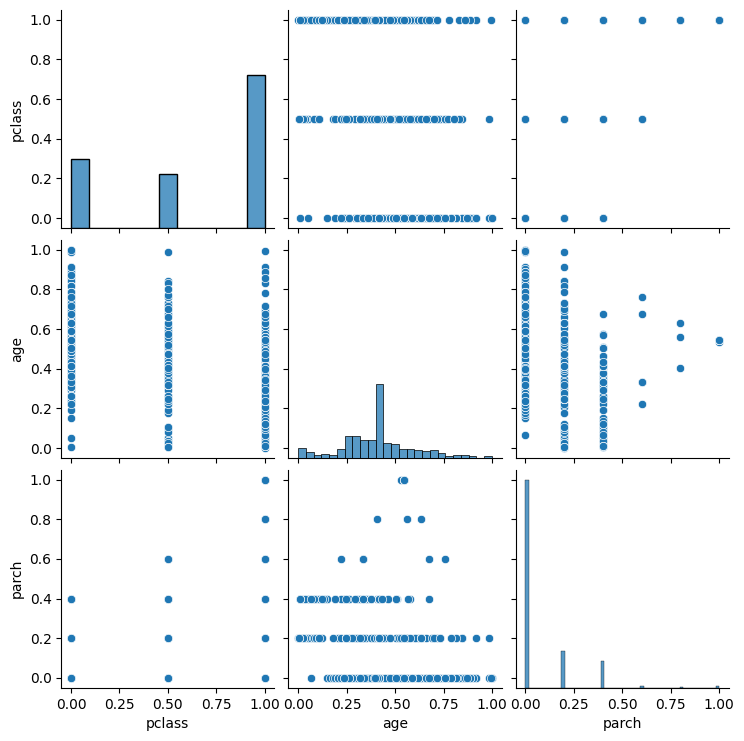

In [101]:
# VISUALIZE PAIRWISE RELATIONSHIPS AFTER MIN-MAX SCALING (RANGE 0-1)
print("\n=>> PAIRPLOT AFTER MIN-MAX SCALING (RANGE 0-1) >>")
sns.pairplot(complete_X_train_MMC)